<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
학습 루프와 옵티마이저
</div>

# 하이퍼파라미터 정의

**목표**: 학습의 3개 외부 레버를 파라미터로 만들어 이후 실험 비교의 기준을 잡습니다.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
learning_rate = 1e-3
batch_size    = 64
epochs        = 5

print("learning_rate =", learning_rate)
print("batch_size    =", batch_size)
print("epochs        =", epochs)

learning_rate = 0.001
batch_size    = 64
epochs        = 5


# FashionMNIST 데이터 준비 + 데이터 들여다보기

**목표**: 데이터를 메모리에 올린 직후 **모양과 클래스 분포를 시각적으로 먼저 확인**합니다. 학습에 들어가기 전에 데이터의 모양을 모르면 잘못된 모델·잘못된 손실 함수를 선택하기 쉽습니다.

In [3]:
training_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.2MB/s]


In [4]:
print("Train data shape:", training_data.data.shape)
print("Test data shape :", test_data.data.shape)

Train data shape: torch.Size([60000, 28, 28])
Test data shape : torch.Size([10000, 28, 28])


In [5]:
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size)

In [6]:
# 데이터 모양 확인
X_batch, y_batch = next(iter(train_dataloader))
print("X_batch.shape =", X_batch.shape)
print("y_batch.shape =", y_batch.shape)
print("훈련 샘플 수  =", len(training_data))
print("평가 샘플 수  =", len(test_data))
print("클래스 종류   =", training_data.classes)

X_batch.shape = torch.Size([64, 1, 28, 28])
y_batch.shape = torch.Size([64])
훈련 샘플 수  = 60000
평가 샘플 수  = 10000
클래스 종류   = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


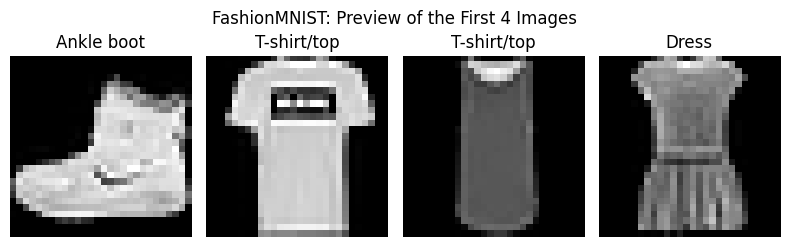

In [7]:
# 첫 4장의 이미지를 미리 보기
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(4):
    axes[i].imshow(X_batch[i, 0], cmap="gray")
    axes[i].set_title(training_data.classes[y_batch[i]])
    axes[i].axis("off")
plt.suptitle("FashionMNIST: Preview of the First 4 Images")
plt.tight_layout()
plt.show()

# 모델 정의 (`NeuralNetwork` MLP)

**목표**: `nn.Module` 패턴으로 3층 다층 퍼셉트론(MLP)을 만들고, 한 배치를 흘려 보내 출력 shape이 `(N, 10)`인지 검증합니다.

In [8]:
class NeuralNetwork(nn.Module): ##nn.Module 반드시 필요
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() # 학습데이터를 받을 수 있는 공간 선언
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512), nn.ReLU(),
            nn.Linear(512,     512), nn.ReLU(),
            nn.Linear(512,      10),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

In [9]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [10]:
# 한 배치를 흘려 보내 출력 shape 확인
pred = model(X_batch)
print("pred.shape =", pred.shape)

pred.shape = torch.Size([64, 10])


# 손실 함수와 옵티마이저 생성

**목표**: 측정(loss)과 갱신(optimizer)을 **두 개의 독립된 객체**로 만들어 학습 루프에 끼울 준비를 합니다.

In [11]:
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
print("loss_fn   =", loss_fn)
print("optimizer =", optimizer)

loss_fn   = CrossEntropyLoss()
optimizer = SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [12]:
# 1 batch forward + loss 시범
loss_demo = loss_fn(model(X_batch), y_batch)
print(f"학습 전 loss(첫 배치) = {loss_demo.item():.4f}")

학습 전 loss(첫 배치) = 2.3073


# `train_loop`로 1 epoch 돌려 보기 (3줄 규약 실습)

**목표**: `zero_grad → backward → step` 3줄을 정확한 순서로 배치한 `train_loop`를 작성하고, 1 epoch을 직접 실행해 loss가 떨어지는 것을 눈으로 확인합니다.

In [14]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()   # ★ 3줄 규약 1
        loss.backward()         # ★ 3줄 규약 2
        optimizer.step()        # ★ 3줄 규약 3

        if batch % 100 == 0: #100번마다 나눠 로그 생성
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

In [15]:
# 1 epoch 시범 실행
print("=== 1 epoch 학습 ===")
train_loop(train_dataloader, model, loss_fn, optimizer)

=== 1 epoch 학습 ===
loss: 2.307338  [   64/60000]
loss: 2.298394  [ 6464/60000]
loss: 2.276596  [12864/60000]
loss: 2.271230  [19264/60000]
loss: 2.256441  [25664/60000]
loss: 2.228806  [32064/60000]
loss: 2.238922  [38464/60000]
loss: 2.204747  [44864/60000]
loss: 2.199447  [51264/60000]
loss: 2.188232  [57664/60000]


# `test_loop`로 평가 삼각 (eval + no_grad + 분모) 갖추기

**목표**: 평가 함수에 `model.eval()` + `with torch.no_grad():` 두 스위치를 모두 켜고, 정확도 분모를 **전체 샘플 수**로 맞춥니다.

In [16]:
def test_loop(dataloader, model, loss_fn):
    model.eval()                              # ★ BN/Dropout 평가 모드

    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    test_loss, correct = 0, 0
    with torch.no_grad():                     # ★ autograd off, !!가장 중요!! torch.no_grad 테스트나 실서비스에서 사용
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(dim=1) == y).type(torch.float).sum().item()

    test_loss /= num_batches                  # 평균 배치 손실
    correct   /= size                         # ★ 전체 샘플 수로 나눔
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

In [17]:
# 1 epoch 후 평가
test_loop(test_dataloader, model, loss_fn)

Test Error: 
 Accuracy: 35.5%, Avg loss: 2.171481 



(2.1714808120849027, 0.3554)

# epoch 메인 루프 + 학습 곡선 시각화

**목표**: 두 함수를 epoch 루프로 묶어 5 epoch을 돌리고, epoch별 정확도·평가 손실을 그래프로 그려 어느 패턴으로 학습 되었는지 판정합니다.

In [18]:
# 모델·옵티마이저를 새로 초기화 (이전 단계의 상태 제거)
model     = NeuralNetwork()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [19]:
history = {"epoch": [], "test_loss": [], "acc": []}
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, acc = test_loop(test_dataloader, model, loss_fn) #test_loss, 테스트할 때 사용
    history["epoch"].append(t + 1)
    history["test_loss"].append(test_loss)
    history["acc"].append(acc * 100)

Epoch 1
-------------------------------
loss: 2.315261  [   64/60000]
loss: 2.298074  [ 6464/60000]
loss: 2.280340  [12864/60000]
loss: 2.263849  [19264/60000]
loss: 2.242745  [25664/60000]
loss: 2.225820  [32064/60000]
loss: 2.223937  [38464/60000]
loss: 2.191744  [44864/60000]
loss: 2.187037  [51264/60000]
loss: 2.145749  [57664/60000]
Test Error: 
 Accuracy: 46.6%, Avg loss: 2.144093 

Epoch 2
-------------------------------
loss: 2.162646  [   64/60000]
loss: 2.143935  [ 6464/60000]
loss: 2.089477  [12864/60000]
loss: 2.096100  [19264/60000]
loss: 2.039229  [25664/60000]
loss: 1.993028  [32064/60000]
loss: 2.012493  [38464/60000]
loss: 1.930241  [44864/60000]
loss: 1.936084  [51264/60000]
loss: 1.856104  [57664/60000]
Test Error: 
 Accuracy: 57.7%, Avg loss: 1.855252 

Epoch 3
-------------------------------
loss: 1.895191  [   64/60000]
loss: 1.855453  [ 6464/60000]
loss: 1.743671  [12864/60000]
loss: 1.778094  [19264/60000]
loss: 1.667443  [25664/60000]
loss: 1.630555  [32064/600

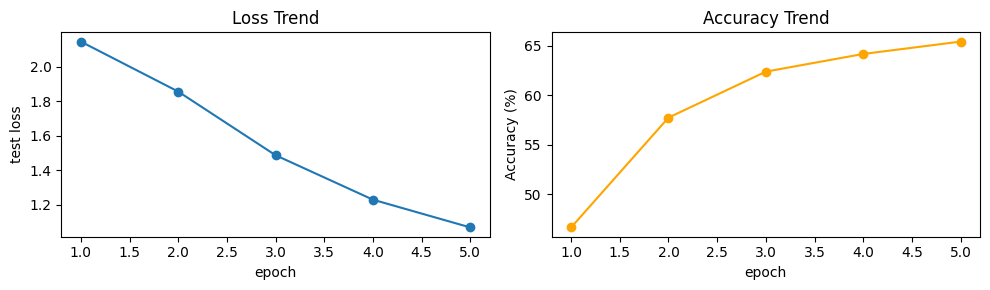

In [20]:
# 학습 곡선 그리기
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(history["epoch"], history["test_loss"], marker="o")
ax1.set_xlabel("epoch"); ax1.set_ylabel("test loss"); ax1.set_title("Loss Trend")
ax2.plot(history["epoch"], history["acc"], marker="o", color="orange")
ax2.set_xlabel("epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Accuracy Trend")
plt.tight_layout()
plt.show()

# Gradient Visualization

In [ ]:
import numpy as np

In [ ]:
# Create a range of x values
x_range = torch.linspace(-3, 3, 100, requires_grad=True)

In [ ]:
# Define a function: f(x) = x^2
y = x_range**2

In [ ]:
# Compute gradients for each x value
gradients = []
for i in range(len(x_range)):
    if x_range.grad is not None:
        x_range.grad.zero_()
    y_i = x_range[i]**2
    y_i.backward()
    gradients.append(x_range.grad[i].item())

In [ ]:
# Convert to NumPy for plotting
x_np = x_range.detach().numpy()
y_np = y.detach().numpy()
gradients_np = np.array(gradients)

In [ ]:
# Plot the function and its gradient
plt.figure(figsize=(10, 6))
plt.plot(x_np, y_np, 'b-', label='f(x) = x^2')
plt.plot(x_np, gradients_np, 'r-', label="f'(x) = 2x")
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function and its Gradient')
plt.legend()
plt.show()